# Technical Indicators

C:\Users\mar_c\AppData\Local\Temp\ipykernel_15000\3369393571.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download('TSLA', start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


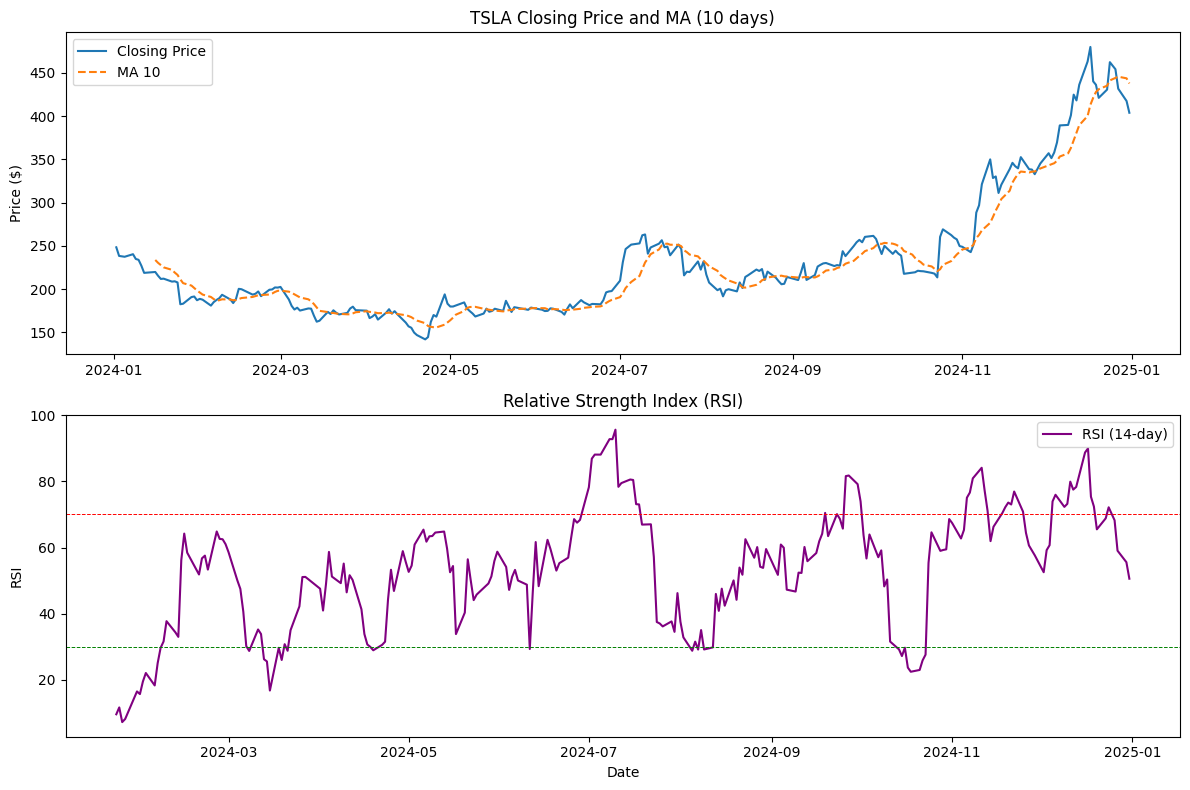

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# Download stock data for TSLA
stock = yf.download('TSLA', start="2024-01-01", end="2025-01-01")

# Calculate 10-day moving average (MA)
stock['MA_10'] = stock['Close'].rolling(window=10).mean()

# RSI Calculation:
delta = stock['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

average_gain = gain.rolling(window=14).mean()
average_loss = loss.rolling(window=14).mean()

rs = average_gain / average_loss
stock['RSI'] = 100 - (100 / (1 + rs))

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Closing Price & MA_10
ax1.plot(stock.index, stock['Close'], label='Closing Price')
ax1.plot(stock.index, stock['MA_10'], linestyle='--', label='MA 10')
ax1.set_title('TSLA Closing Price and MA (10 days)')
ax1.set_ylabel('Price ($)')
ax1.legend()

# RSI
ax2.plot(stock.index, stock['RSI'], label='RSI (14-day)', color='purple')
ax2.axhline(70, color='red', linestyle='--', linewidth=0.7)
ax2.axhline(30, color='green', linestyle='--', linewidth=0.7)
ax2.set_title('Relative Strength Index (RSI)')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()




# Lag Features


In [3]:
stock['Lag_1'] = stock['Close'].shift(1)
stock['Lag_2'] = stock['Close'].shift(2)
stock['Lag_3'] = stock['Close'].shift(3)
print(stock.head())

Price            Close        High         Low        Open     Volume MA_10  \
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA         
Date                                                                          
2024-01-02  248.419998  251.250000  244.410004  250.080002  104654200   NaN   
2024-01-03  238.449997  245.679993  236.320007  244.979996  121082600   NaN   
2024-01-04  237.929993  242.699997  237.729996  239.250000  102629300   NaN   
2024-01-05  237.490005  240.119995  234.899994  236.860001   92488900   NaN   
2024-01-08  240.449997  241.250000  235.300003  236.139999   85166600   NaN   

Price      RSI       Lag_1       Lag_2       Lag_3  
Ticker                                              
Date                                                
2024-01-02 NaN         NaN         NaN         NaN  
2024-01-03 NaN  248.419998         NaN         NaN  
2024-01-04 NaN  238.449997  248.419998         NaN  
2024-01-05 NaN  237.929993  238.449997  248.41999

# Rolling Window Statistics

In [4]:
stock['Rolling_Mean_5'] = stock['Close'].rolling(window=5).mean()
stock['Rolling_Median_5'] = stock['Close'].rolling(window=5).median()
stock['Rolling_Std_5'] = stock['Close'].rolling(window=5).std()
print(stock.tail())

Price            Close        High         Low        Open    Volume  \
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA   
Date                                                                   
2024-12-24  462.279999  462.779999  435.140015  435.899994  59551800   
2024-12-26  454.130005  465.329987  451.019989  465.160004  76366400   
2024-12-27  431.660004  450.000000  426.500000  449.519989  82666800   
2024-12-30  417.410004  427.000000  415.750000  419.399994  64941000   
2024-12-31  403.839996  427.929993  402.540009  423.790009  76825100   

Price            MA_10        RSI       Lag_1       Lag_2       Lag_3  \
Ticker                                                                  
Date                                                                    
2024-12-24  441.222000  72.174769  430.600006  421.059998  436.170013   
2024-12-26  444.158002  68.250827  462.279999  430.600006  421.059998   
2024-12-27  445.514001  59.044415  454.130005  462.279999 

# Price Volatility

In [5]:
stock['Daily_Volatility'] = stock['Close'].pct_change().rolling(window=5).std()
print(stock.tail())

Price            Close        High         Low        Open    Volume  \
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA   
Date                                                                   
2024-12-24  462.279999  462.779999  435.140015  435.899994  59551800   
2024-12-26  454.130005  465.329987  451.019989  465.160004  76366400   
2024-12-27  431.660004  450.000000  426.500000  449.519989  82666800   
2024-12-30  417.410004  427.000000  415.750000  419.399994  64941000   
2024-12-31  403.839996  427.929993  402.540009  423.790009  76825100   

Price            MA_10        RSI       Lag_1       Lag_2       Lag_3  \
Ticker                                                                  
Date                                                                    
2024-12-24  441.222000  72.174769  430.600006  421.059998  436.170013   
2024-12-26  444.158002  68.250827  462.279999  430.600006  421.059998   
2024-12-27  445.514001  59.044415  454.130005  462.279999 

# Sentiment Analysis

In [6]:
from textblob import TextBlob

news_headlines = [
    "Apple reports record profits amid increased iPhone sales.",
    "Tesla faces recall as safety concerns rise over autopilot issues.",
    "Microsoft stock surges following strong quarterly earnings report.",
    "Google hit by massive lawsuit related to privacy concerns.",
    "Amazon to lay off thousands of employees due to declining revenues."
]

for headline in news_headlines:
    sentiment_score = TextBlob(headline).sentiment.polarity
    sentiment_label = "Positive" if sentiment_score > 0 else "Negative" if sentiment_score < 0 else "Neutral"
    print(f"Headline: {headline}")
    print(f"Sentiment Score: {sentiment_score:.2f}, Sentiment: {sentiment_label}\n")


Headline: Apple reports record profits amid increased iPhone sales.
Sentiment Score: 0.00, Sentiment: Neutral

Headline: Tesla faces recall as safety concerns rise over autopilot issues.
Sentiment Score: 0.00, Sentiment: Neutral

Headline: Microsoft stock surges following strong quarterly earnings report.
Sentiment Score: 0.22, Sentiment: Positive

Headline: Google hit by massive lawsuit related to privacy concerns.
Sentiment Score: 0.00, Sentiment: Neutral

Headline: Amazon to lay off thousands of employees due to declining revenues.
Sentiment Score: -0.12, Sentiment: Negative



# Macroeconomic Indicators

In [ ]:
economic_data = {'GDP_Growth': [2.1, 2.3, 2.5], 'Unemployment_Rate': [4.5, 4.3, 4.1]}
econ_df = pd.DataFrame(economic_data)  
print(econ_df)

   GDP_Growth  Unemployment_Rate
0         2.1                4.5
1         2.3                4.3
2         2.5                4.1
